In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv('heart_disease_uci.csv')

# Inspect
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.head())

(920, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fb

In [13]:
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df = df.drop(columns=['num'])

# Handle missing values (common in this dataset)
df = df.dropna(subset=['target'])  # drop rows with no label
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Convert categorical text columns to numbers
df = pd.get_dummies(df, drop_first=True)

/tmp/ipykernel_2122/1974428906.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


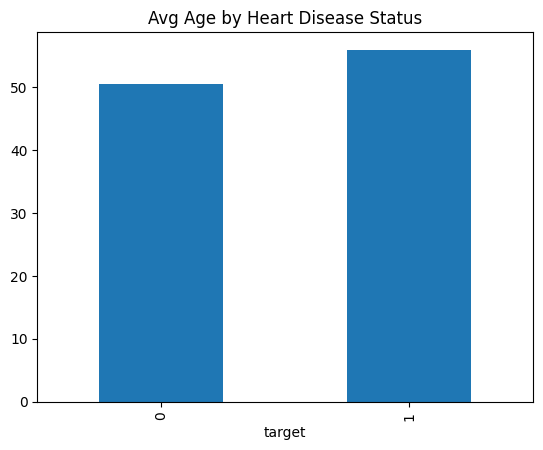

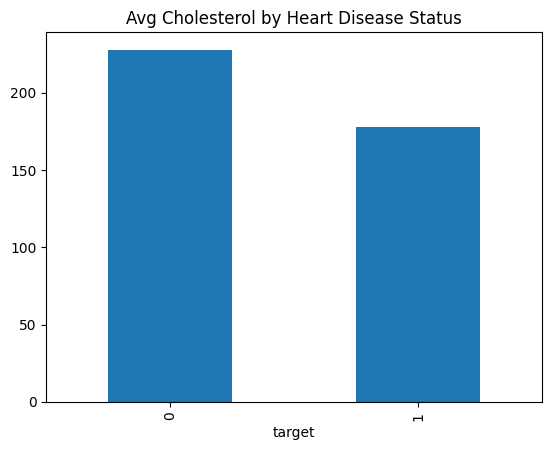

In [4]:
import matplotlib.pyplot as plt

df.groupby('target')['age'].mean().plot(kind='bar', title='Avg Age by Heart Disease Status')
plt.show()

df.groupby('target')['chol'].mean().plot(kind='bar', title='Avg Cholesterol by Heart Disease Status')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier(random_state=42)

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

for name, model in [('Logistic Regression', log_model), ('Random Forest', rf_model)]:
    preds = model.predict(X_test)
    print(f"\n--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))


--- Logistic Regression ---
Accuracy: 0.842391304347826
Precision: 0.8846153846153846
Recall: 0.8440366972477065
Confusion Matrix:
 [[63 12]
 [17 92]]

--- Random Forest ---
Accuracy: 0.875
Precision: 0.9056603773584906
Recall: 0.8807339449541285
Confusion Matrix:
 [[65 10]
 [13 96]]


In [14]:
print((df['chol'] == 0).sum())
print(df[df['chol'] == 0]['target'].value_counts())

172
target
1    152
0     20
Name: count, dtype: int64


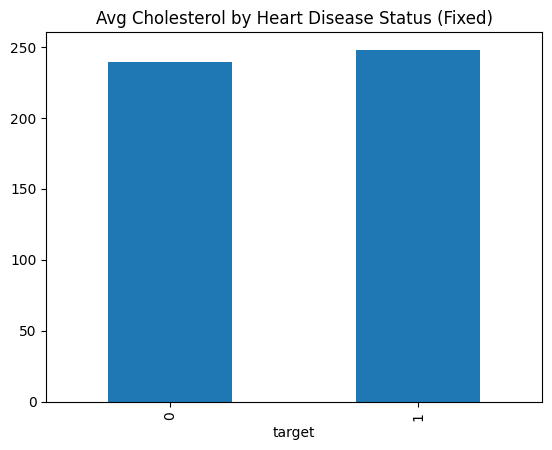

In [15]:
# Fix the disguised missing values
df['chol'] = df['chol'].replace(0, np.nan)
df['chol'] = df['chol'].fillna(df['chol'].median())

# Re-check the chart
df.groupby('target')['chol'].mean().plot(kind='bar', title='Avg Cholesterol by Heart Disease Status (Fixed)')
plt.show()

In [16]:
# Re-run your train/test split and model training with the corrected df
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Re-evaluate
for name, model in [('Logistic Regression', log_model), ('Random Forest', rf_model)]:
    preds = model.predict(X_test)
    print(f"\n--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Logistic Regression ---
Accuracy: 0.8478260869565217
Precision: 0.8857142857142857
Recall: 0.8532110091743119

--- Random Forest ---
Accuracy: 0.875
Precision: 0.8981481481481481
Recall: 0.8899082568807339
